In [1]:
# === SESSION BOOTSTRAP ===
from google.colab import drive
drive.mount('/content/drive')
import os, subprocess, sys
PARENT="/content/drive/MyDrive/UAV_TRUST_Research"; REPO=f"{PARENT}/uav-trust-research"
for fn in (".gitconfig",".git-credentials"):
    p=os.path.join(PARENT,fn)
    if os.path.exists(p): subprocess.run(f'cp "{p}" /root/{fn}',shell=True)
subprocess.run("git config --global credential.helper store",shell=True)
if os.path.isdir(REPO):
    os.chdir(REPO); sys.path.insert(0,REPO) if REPO not in sys.path else None; print("cwd:",os.getcwd())
else: print("run 00_setup first")

Mounted at /content/drive
cwd: /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research


In [2]:
!pip install pandas numpy pyarrow matplotlib --quiet

In [3]:
# One-time conversion of the 2.4 GB UAV-CAS time-series CSV to a compact Parquet cache,
# plus inspection of sequence lengths and class balance to choose a sequence architecture.
CAS_TS_CSV="/content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research/data/uav_cas/UAV-CAS_ts.csv"
CAS_TS_PARQUET="/content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research/data/uav_cas/uav_cas_ts.parquet"
SINGLE={"benign","dos","ddos","blackhole","wormhole","replay"}   # six single-family classes; "+"-labels excluded
LIST_COLS=["packet_time","packet_size","packet_dir"]            # sequence columns we use
CHUNK=8000                                                       # rows per chunk (memory-safe streaming read)
print("configured")

configured


In [4]:
import pandas as pd, numpy as np, json, ast, os, gc
import matplotlib.pyplot as plt

# ---- 1) peek the header so we read only the columns we need ----
head=pd.read_csv(CAS_TS_CSV, nrows=3)
print("columns present:", list(head.columns))
print("\nsample of first row (truncated):")
for col in head.columns:
    v=str(head[col].iloc[0]); print(f"  {col}: {v[:80]}{'...' if len(v)>80 else ''}")
usecols=[c for c in LIST_COLS+["Label"] if c in head.columns]
print("\nreading columns:", usecols)
assert set(LIST_COLS+["Label"]).issubset(set(head.columns)), "expected columns missing"

columns present: ['packet_time', 'packet_size', 'packet_dir', 'Label']

sample of first row (truncated):
  packet_time: [1778976386.715261, 1778976389.787248, 1778976389.787264, 1778976392.859254, 177...
  packet_size: [104, 104, 104, 104, 104, 104, 104, 104, 104, 104, 104, 104, 104, 104, 104, 104,...
  packet_dir: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1...
  Label: Benign

reading columns: ['packet_time', 'packet_size', 'packet_dir', 'Label']


In [5]:
# ---- 2) stream the CSV in chunks: filter six classes, parse list columns, keep parsed data ----
def parse_list(s):
    if isinstance(s,(list,tuple)): return list(s)
    try: return json.loads(s)
    except Exception: return ast.literal_eval(s)

parts=[]; lengths=[]; n_raw=0; n_kept=0
reader=pd.read_csv(CAS_TS_CSV, usecols=usecols, chunksize=CHUNK)
for ci,ch in enumerate(reader):
    n_raw+=len(ch)
    lab=ch["Label"].astype(str)
    keep=lab.str.lower().isin(SINGLE) & (~lab.str.contains("+", regex=False))
    ch=ch[keep]
    if len(ch)==0: continue
    for col in LIST_COLS: ch[col]=ch[col].apply(parse_list)
    lengths.extend(ch["packet_time"].apply(len).tolist())
    parts.append(ch.reset_index(drop=True)); n_kept+=len(ch)
    if (ci+1)%20==0: print(f"  processed ~{n_raw} rows, kept {n_kept}")
ts=pd.concat(parts,ignore_index=True); del parts; gc.collect()
lengths=np.array(lengths)
print(f"\ndone. raw rows {n_raw}, kept (six single-family classes) {n_kept}")

/tmp/ipykernel_674/693832267.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for col in LIST_COLS: ch[col]=ch[col].apply(parse_list)
/tmp/ipykernel_674/693832267.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for col in LIST_COLS: ch[col]=ch[col].apply(parse_list)
/tmp/ipykernel_674/693832267.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda


done. raw rows 99492, kept (six single-family classes) 92131


In [6]:
# ---- 3) inspect: sequence-length distribution + class balance ----
print("=== sequence length (packets per flow) ===")
for q in [0,5,25,50,75,90,95,99,100]:
    print(f"  {q:3d}th pct: {np.percentile(lengths,q):.0f}")
print(f"  mean {lengths.mean():.1f}  total packets {lengths.sum():,}")
print("\n=== class balance (six single-family) ===")
print(ts["Label"].value_counts().to_string())
# recommend a padding length + architecture
L=int(np.percentile(lengths,95))
print(f"\nsuggested pad/truncate length L = 95th pct = {L}")
frac_capped=float((lengths>L).mean())
print(f"fraction of flows longer than L (truncated): {frac_capped:.3f}")
if np.percentile(lengths,95)<=64: arch="1D-CNN or masked mean-pool over packets (short sequences)"
elif np.percentile(lengths,95)<=400: arch="1D-CNN with global pooling, or a small GRU/LSTM (moderate sequences)"
else: arch="1D-CNN with strided pooling (long sequences; full LSTM may be slow)"
print("suggested architecture:", arch)

=== sequence length (packets per flow) ===
    0th pct: 10
    5th pct: 73
   25th pct: 358
   50th pct: 663
   75th pct: 1081
   90th pct: 1095
   95th pct: 1105
   99th pct: 8076
  100th pct: 18438
  mean 864.0  total packets 79,602,832

=== class balance (six single-family) ===
Label
Benign       58589
Blackhole    12116
Wormhole     10862
DDoS          7316
Replay        2025
DoS           1223

suggested pad/truncate length L = 95th pct = 1105
fraction of flows longer than L (truncated): 0.044
suggested architecture: 1D-CNN with strided pooling (long sequences; full LSTM may be slow)


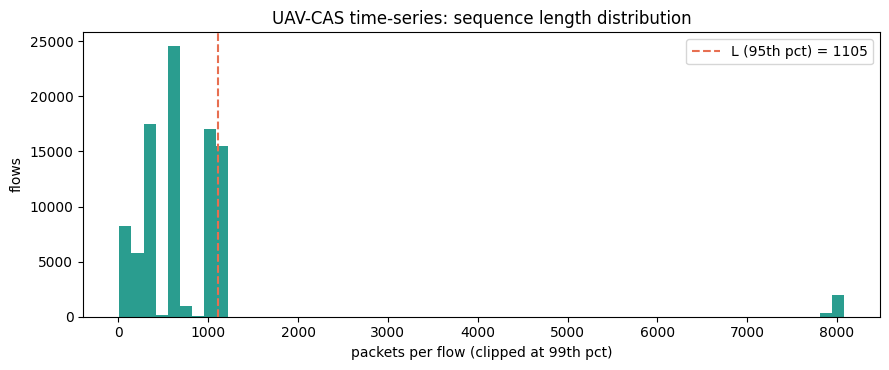

In [7]:
# ---- 4) length histogram ----
fig,ax=plt.subplots(figsize=(9,3.8))
ax.hist(np.clip(lengths,0,np.percentile(lengths,99)),bins=60,color="#2a9d8f")
ax.axvline(L,ls="--",color="#e76f51",label=f"L (95th pct) = {L}")
ax.set_xlabel("packets per flow (clipped at 99th pct)"); ax.set_ylabel("flows"); ax.set_title("UAV-CAS time-series: sequence length distribution")
ax.legend(); fig.tight_layout(); plt.show()

In [8]:
# ---- 5) write the compact Parquet cache (parsed lists), so the 2.4 GB CSV is never read again ----
os.makedirs(os.path.dirname(CAS_TS_PARQUET),exist_ok=True)
ts.to_parquet(CAS_TS_PARQUET, engine="pyarrow", compression="zstd", index=False)
sz=os.path.getsize(CAS_TS_PARQUET)/1e6
print(f"cached -> {CAS_TS_PARQUET}  ({sz:.1f} MB, vs 2.4 GB CSV)")
# quick reload check
back=pd.read_parquet(CAS_TS_PARQUET)
print("reload rows:",len(back),"| cols:",list(back.columns))
print("first flow packet_time length:",len(back['packet_time'].iloc[0]),"| label:",back['Label'].iloc[0])

cached -> /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research/data/uav_cas/uav_cas_ts.parquet  (196.7 MB, vs 2.4 GB CSV)
reload rows: 92131 | cols: ['packet_time', 'packet_size', 'packet_dir', 'Label']
first flow packet_time length: 205 | label: Benign
